In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("../data/processed/clean_twitter.csv")

df.head()

,id,label,tweet,clean_tweet
0,1,0,@user when a father is dysfunctional and is s...,father dysfunct selfish drag kid dysfunct run
1,2,0,@user @user thanks for #lyft credit i can't us...,thank lyft credit cant use caus dont offer whe...
2,3,0,bihday your majesty,bihday majesti
3,4,0,#model i love u take with u all the time in ...,model love u take u time ur
4,5,0,factsguide: society now #motivation,factsguid societi motiv


In [2]:
X = df['clean_tweet']
y = df['label']

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf=TfidfVectorizer(max_features=5000)
X=tfidf.fit_transform(X)

In [4]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

### Model Building

### Train

In [14]:
model.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

### Test

In [15]:
y_pred=model.predict(X_test)
print(y_pred[:10])

[0 0 0 0 1 0 0 0 0 0]


In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.93      0.96      5938
           1       0.47      0.83      0.60       448

    accuracy                           0.92      6386
   macro avg       0.73      0.88      0.78      6386
weighted avg       0.95      0.92      0.93      6386



In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[5515  423]
 [  78  370]]


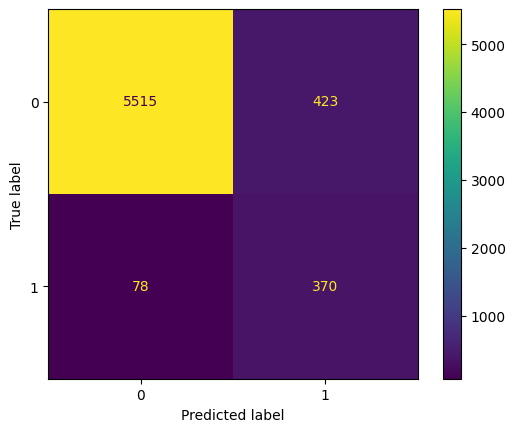

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.show()

In [ ]:
import joblib

In [21]:
joblib.dump(model, "../models/sentiment_model.pkl")

['../models/sentiment_model.pkl']

In [22]:
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

['../models/tfidf_vectorizer.pkl']

In [23]:
import os

print(os.listdir("../models"))

['sentiment_model.pkl', 'tfidf_vectorizer.pkl']


In [24]:
import joblib

model = joblib.load("../models/sentiment_model.pkl")

print(type(model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>
